In [1]:
import torch
from torch.nn import Module, Linear
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from numpy import random

In [2]:
class MyNet(Module):
    def __init__(self):
        super().__init__()
        self.fc1 = Linear(10,800)
        self.fc2 = Linear(800,10)
    
    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        return x

In [3]:
class ContextBandit:
    """上下文老虎机 (Contextual Bandit) 环境.

    每一步环境处于某个 state (context), agent 选择一个 arm, 环境返回一个整数奖励.
    与普通多臂老虎机的区别: 每个 arm 的中奖概率随 state 变化, 因此 agent 必须学会
    "在什么 state 下拉哪只 arm", 即一个从 state 到 arm 的策略.
    """

    def __init__(self, states=10, arms=10):
        self.arms = arms       # arm 数量 (动作空间大小)
        self.states = states   # state 数量 (上下文空间大小)

        # 中奖概率矩阵, 形状 (states, arms), 每个元素 ∈ [0, 1).
        # init_distri[s, a] = 在 state s 下拉动 arm a 的单次伯努利成功概率.
        # 环境初始化后固定不变, agent 需要通过采样去学出它的结构.
        self.init_distri = random.rand(self.states, self.arms)

        self.update_state()  # 随机初始化当前 state

    def reward(self, prob):
        # 给定成功概率 prob (标量), 抽取一次 Binomial(n=arms, p=prob) 作为奖励.
        # 等价写法: np.random.binomial(self.arms, prob).
        # 这样奖励是 0..arms 的整数, 比单次伯努利 {0, 1} 信号更丰富,
        # 单步样本就能区分 prob=0.3 与 prob=0.7.
        return (random.rand(self.arms) < prob).sum()

    def get_state(self):
        # 返回当前 state (int), 供 agent 作为网络输入
        return self.state

    def update_state(self):
        # 状态转移: 均匀随机跳到 [0, states) 中的任一 state.
        # 注意此环境的转移与 action 无关 (与真正的 MDP 不同),
        # 所以这是 contextual bandit 而非完整强化学习.
        self.state = random.randint(0, self.states)

    def get_reward(self, arm):
        # 用 (当前 state, 选中的 arm) 从概率矩阵中查出 prob, 再采样奖励
        return self.reward(self.init_distri[self.get_state()][arm])

    def choose_arm(self, arm: int) -> int:
        # 环境对外的主要接口: 先在当前 state 下用选中的 arm 获取奖励,
        # 再推进到下一个 state, 返回奖励.
        # 调用顺序保证 agent 下一次 get_state() 拿到的是新 state.
        r = self.get_reward(arm)
        self.update_state()
        return r

In [4]:
states = 10
arms = 10
N, D_in, H, D_out = 1, states, 100, arms
learning_rate = 0.01

In [5]:
model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
    torch.nn.ReLU(),
)

In [6]:
loss_fn = torch.nn.MSELoss()

In [7]:
def softmax(p:np.array, tau = 1):
    return np.exp(p/tau) / (np.exp(p/tau).sum())

def one_hot(n, pos, val=1):
    mask = np.zeros(n)
    mask[pos] = val
    return mask

In [8]:
env = ContextBandit(states, arms)

In [9]:
env.get_state()

6

Text(0, 0.5, 'reward (moving avg, window=100)')

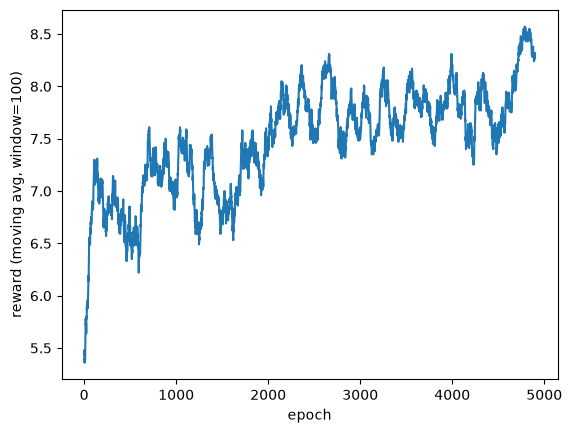

In [10]:
def train(env, epochs=5000, learning_rate=1e-2):

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    rewards: list = []

    for _ in range(epochs):

        # state 是 int, 用 one-hot 编码成向量输入网络
        state = one_hot(states, env.get_state(), 1)
        # nn.Linear 要求 float32, numpy 默认 float64, 显式转成 float32
        state = torch.from_numpy(state).float()

        # 网络输出 10 维, 视作每个 arm 的 Q 值
        logits = model(state)

        # softmax 得到动作分布, dim=-1 沿 arm 维度归一化
        probs = F.softmax(logits, dim=-1)

        # detach() 是必须的: np.random.choice 不接受带梯度的 tensor,
        # 且采样这一步本身也不该反传梯度
        arm = np.random.choice(
            arms,
            p=probs.detach().numpy()
        )

        reward = env.choose_arm(arm)
        rewards.append(reward)

        # 关键 trick: target 除了被选中的 arm 之外, 其他分量都等于当前预测,
        # 这样 MSELoss 对未选 arm 的梯度为 0, 只更新被选 arm 的 Q 值,
        # 效果等价于只对 logits[arm] 做回归, 但省去了单独切片
        target = logits.detach().clone()
        target[arm] = reward

        loss = loss_fn(logits, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return rewards


rewards = train(env)

# reward 是 0..10 的整数, 直接散点会重叠成 11 条横带看不出趋势,
# 用滑动平均把学习曲线显式画出来
window = 100
smooth = np.convolve(rewards, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(1, 1)
ax.plot(smooth)
ax.set_xlabel("epoch")
ax.set_ylabel(f"reward (moving avg, window={window})")
